In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [2]:
connection = sqlite3.connect('../../data/checking-logs.sqlite')
query = '''
SELECT
    uid,
    timestamp,
    CASE strftime('%w', timestamp)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS weekday,
    CAST(strftime('%H', timestamp) AS INTEGER) AS hour
FROM
    checker
WHERE
    uid LIKE 'user_%'
'''
df = pd.read_sql(query, connection)

connection.close()

In [3]:
ordered_weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

week_df = (
    df.groupby(['weekday', 'uid'])['uid']
      .size()
      .unstack('uid')
      .reindex(ordered_weekdays)
      .fillna(0)
)
week_df = week_df[week_df.sum().sort_values(ascending=False).index]

hour_df = (
    df.groupby(['hour', 'uid'])['uid']
      .size()
      .unstack('uid')
      .fillna(0)
      .sort_index()
)
hour_df = hour_df[week_df.columns]

hour_df = hour_df.reindex(range(24), fill_value=0)

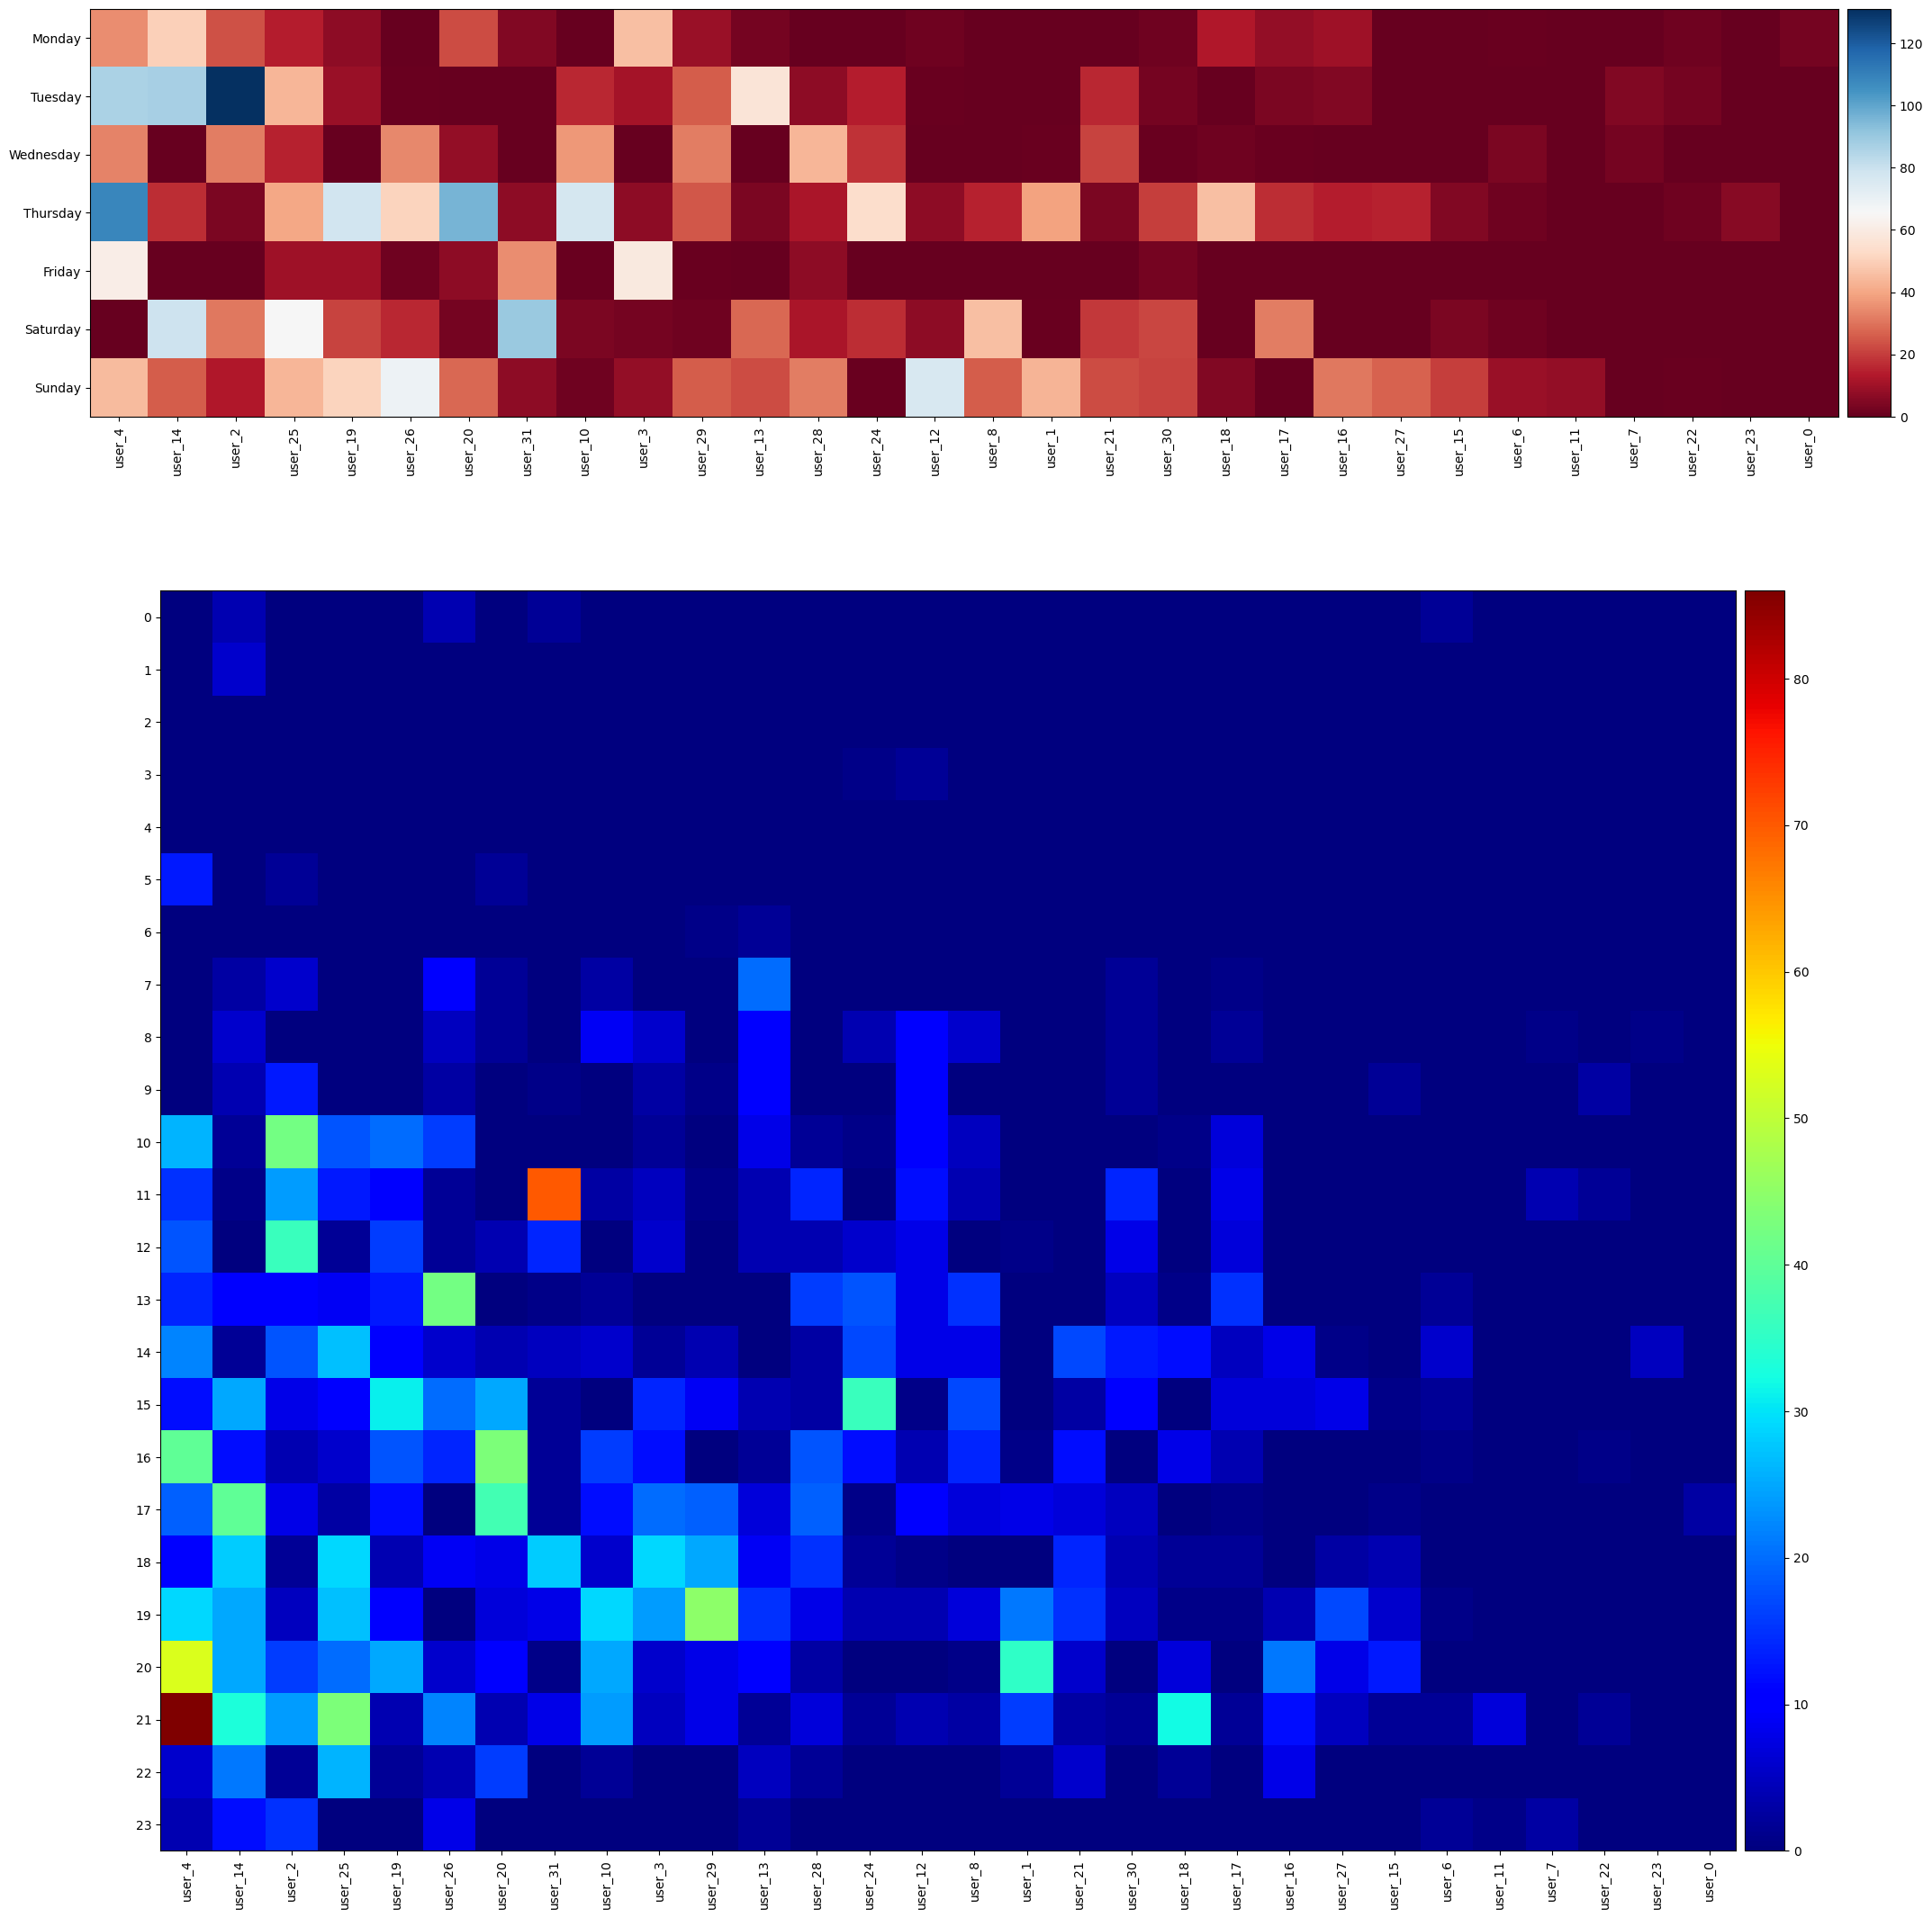

In [4]:
n_weekdays, n_users = week_df.shape
n_hours = hour_df.shape[0]

fig, (top_ax, bot_ax) = plt.subplots(nrows=2, ncols=1, figsize=(20, 14))

divider_top = make_axes_locatable(top_ax)
cbar_ax_top = divider_top.append_axes("right", size="2.5%", pad=0.1)

img_top = top_ax.imshow(week_df.values, aspect='equal', cmap='RdBu')
top_ax.set_yticks(range(n_weekdays))
top_ax.set_yticklabels(week_df.index)
top_ax.set_xticks(range(n_users))
top_ax.set_xticklabels(week_df.columns, rotation=90)
plt.colorbar(img_top, cax=cbar_ax_top)

#################
divider_bottom = make_axes_locatable(bot_ax)
cbar_ax_bottom = divider_bottom.append_axes("right", size="2.5%", pad=0.1)

img_bottom = bot_ax.imshow(hour_df.values, aspect='equal', cmap='jet')
bot_ax.set_yticks(range(n_hours))
bot_ax.set_yticklabels(hour_df.index)
bot_ax.set_xticks(range(n_users))
bot_ax.set_xticklabels(hour_df.columns, rotation=90)
plt.colorbar(img_bottom, cax=cbar_ax_bottom)

top_ax.set_position([0, 1, 1, 1])
bot_ax.set_position([-0.01, 0.2, 1, 1])
plt.show()

## Questions
"Which user has the most commits on Tue?” The answer: **user2**.

“Which user has the most commits on Thu?” The answer: **user4**.

"On which weekday do the users not like making a lot of commits?” The
answer is **Friday**.

“Which user at which hour made the largest number of commits?” The answer is **user4, 21st hour**.